# Demonstration: The Indefinite Integral and the Mass of the Earth

Math 140H, Honors Calculus I

The **indefinite integral** of $f$ is the integral viewed as a function of its upper limit (C&J Section 2.4):

$$\Phi(x) = \int_\alpha^x f(u)\,du.$$

This demonstration uses real geophysical data. If $\rho(u)$ is the density of the Earth at distance $u$ from its center, then a thin spherical shell of radius $u$ and thickness $\Delta u$ has mass close to $4\pi u^2 \rho(u)\,\Delta u$, and adding up shells gives

$$M(x) = \int_0^x 4\pi u^2 \rho(u)\,du = \text{mass of the Earth within distance } x \text{ of the center}.$$

Nobody needs a single value of $M$ so much as the whole function: how much mass is in the core, which sphere holds half of Earth's mass, how gravity changes as you go down. All of these are questions about $M$ as a function of $x$.

The density data come from the Preliminary Reference Earth Model (PREM) of Dziewonski and Anderson (1981), the standard model of Earth's interior in seismology.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7.5, 4.5)
plt.rcParams['axes.grid'] = True

a = 6371.0e3          # Earth's radius (m)
G = 6.6743e-11        # gravitational constant (m^3 kg^-1 s^-2)
M_known = 5.9722e24   # Earth's measured mass (kg)

# PREM density: (inner radius km, outer radius km, name, [c0, c1, c2, c3]),
# rho = c0 + c1 x + c2 x^2 + c3 x^3 in g/cm^3, with x = r / a
PREM_LAYERS = [
    (   0.0, 1221.5, 'inner core',        [13.0885,  0.0,    -8.8381,  0.0   ]),
    (1221.5, 3480.0, 'outer core',        [12.5815, -1.2638, -3.6426, -5.5281]),
    (3480.0, 5701.0, 'lower mantle',      [ 7.9565, -6.4761,  5.5283, -3.0807]),
    (5701.0, 5771.0, 'transition zone 1', [ 5.3197, -1.4836,  0.0,     0.0   ]),
    (5771.0, 5971.0, 'transition zone 2', [11.2494, -8.0298,  0.0,     0.0   ]),
    (5971.0, 6151.0, 'transition zone 3', [ 7.1089, -3.8045,  0.0,     0.0   ]),
    (6151.0, 6346.6, 'upper mantle',      [ 2.6910,  0.6924,  0.0,     0.0   ]),
    (6346.6, 6356.0, 'lower crust',       [ 2.900,   0.0,     0.0,     0.0   ]),
    (6356.0, 6368.0, 'upper crust',       [ 2.600,   0.0,     0.0,     0.0   ]),
    (6368.0, 6371.0, 'ocean',             [ 1.020,   0.0,     0.0,     0.0   ]),
]
BOUNDARIES = np.array([L[1] for L in PREM_LAYERS]) * 1e3
R_ICB, R_CMB = 1221.5e3, 3480.0e3   # inner core boundary, core-mantle boundary

def rho(r):
    # PREM density (kg/m^3) at radius r (m); works on arrays
    r = np.asarray(r, dtype=float)
    idx = np.clip(np.searchsorted(BOUNDARIES, r, side='right'), 0, len(PREM_LAYERS) - 1)
    coeffs = np.array([L[3] for L in PREM_LAYERS])[idx]
    x = r / a
    return 1000.0 * np.sum(coeffs * np.stack([np.ones_like(x), x, x**2, x**3], axis=-1), axis=-1)

def integrand(u):
    return 4 * np.pi * u**2 * rho(u)

def M_exact(x):
    # exact M(x) from the power rule  int u^p du = (b^{p+1} - a^{p+1}) / (p+1),  plus additivity over layers
    total = 0.0
    for r0, r1, name, c in PREM_LAYERS:
        s0, s1 = r0 * 1e3 / a, min(r1 * 1e3, x) / a
        if s1 <= s0:
            break
        total += sum(ck * (s1**(k + 3) - s0**(k + 3)) / (k + 3) for k, ck in enumerate(c))
    return 4 * np.pi * a**3 * total * 1000.0

def bisect(F, target, lo, hi, tol=1.0):
    # solve F(x) = target for continuous increasing F by nested intervals
    while hi - lo > tol:
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if F(mid) < target else (lo, mid)
    return (lo + hi) / 2

def plot_layers(f, ax, **kwargs):
    # plot a piecewise function layer by layer, so jumps appear as breaks
    for k, (r0, r1, name, c) in enumerate(PREM_LAYERS):
        rr = np.linspace(r0 * 1e3, r1 * 1e3 - 1e-6, 400)
        ax.plot(rr / 1e3, f(rr), **(kwargs if k == 0 else {kk: v for kk, v in kwargs.items() if kk != 'label'}))

def mark_boundaries(ax):
    for rb in [R_ICB, R_CMB]:
        ax.axvline(rb / 1e3, color='gray', linestyle='--', linewidth=0.8)

x_vals = np.linspace(1e3, a, 1500)
M_vals = np.array([M_exact(x) for x in x_vals])
M_a = M_exact(a)

## 1. The density of the Earth

PREM divides the Earth into spherical layers, and within each layer the density is a polynomial of degree at most 3 in $r/a$. The density is **not continuous**: it jumps where the solid inner core meets the liquid outer core, where the iron core meets the rocky mantle, and at several smaller boundaries near the surface. A function with finitely many jumps like this is still integrable.

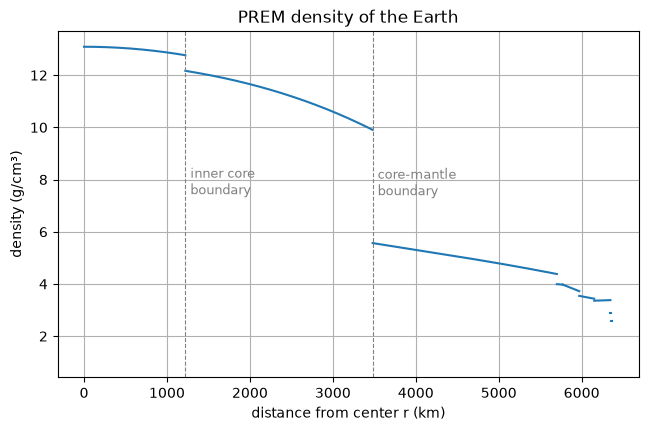

In [2]:
fig, ax = plt.subplots()
plot_layers(lambda r: rho(r) / 1000, ax, color='C0')
mark_boundaries(ax)
ax.text(R_ICB / 1e3 + 60, 8.5, 'inner core\nboundary', fontsize=9, color='gray', va='top')
ax.text(R_CMB / 1e3 + 60, 8.5, 'core-mantle\nboundary', fontsize=9, color='gray', va='top')
ax.set_xlabel('distance from center r (km)')
ax.set_ylabel('density (g/cm³)')
ax.set_title('PREM density of the Earth')
plt.show()

## 2. The total mass from Riemann sums

Cutting the Earth into $n$ shells of thickness $\Delta u = a/n$ gives the Riemann sum $\sum 4\pi u_i^2 \rho(u_i)\,\Delta u$. As $n$ grows, the sums converge to the integral $\int_0^a 4\pi u^2\rho(u)\,du$, which we can also evaluate exactly with the power rule because $\rho$ is a polynomial on each layer. The result matches Earth's mass as measured from satellite orbits, $5.972\times 10^{24}$ kg, to about four digits.

In [3]:
print(f'{"shells n":>10}   {"Riemann sum (kg)":>17}')
for n in [10, 100, 1000, 10_000, 100_000]:
    du = a / n
    u = np.arange(1, n + 1) * du
    print(f'{n:>10}   {np.sum(integrand(u)) * du:17.5e}')
print(f'{"exact":>10}   {M_a:17.5e}')
print(f'{"measured":>10}   {M_known:17.5e}')

  shells n    Riemann sum (kg)
        10         5.76749e+24
       100         5.95623e+24
      1000         5.97601e+24
     10000         5.97356e+24
    100000         5.97318e+24
     exact         5.97318e+24
  measured         5.97220e+24


## 3. The integral as a function of its upper limit

Now let the upper limit vary. The left panel shows the integrand $4\pi u^2\rho(u)$ with the area from $0$ to $x$ shaded, for $x$ at the core-mantle boundary. The right panel shows the whole function $M(x)$: the dot is the shaded area, plotted as a height. Every point on the right-hand curve is one shaded area on the left.

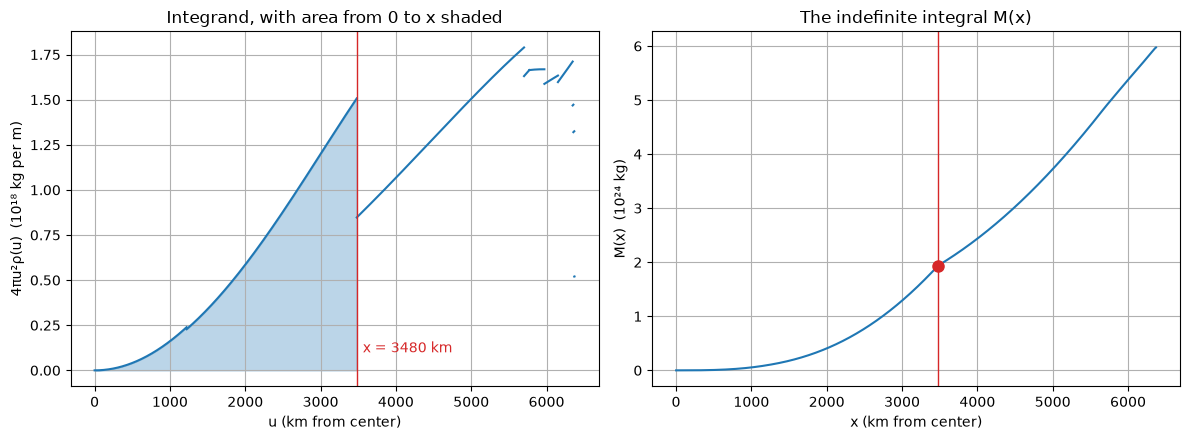

mass of the core: 1.940e+24 kg


In [4]:
x_show = R_CMB
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

plot_layers(lambda u: integrand(u) / 1e18, ax1, color='C0')
uu = np.linspace(0, x_show - 1e-6, 1000)
ax1.fill_between(uu / 1e3, integrand(uu) / 1e18, alpha=0.3, color='C0')
ax1.axvline(x_show / 1e3, color='C3', linewidth=1)
ax1.text(x_show / 1e3 + 80, 0.1, f'x = {x_show / 1e3:.0f} km', color='C3')
ax1.set_xlabel('u (km from center)')
ax1.set_ylabel('4πu²ρ(u)  (10¹⁸ kg per m)')
ax1.set_title('Integrand, with area from 0 to x shaded')

ax2.plot(x_vals / 1e3, M_vals / 1e24, color='C0')
ax2.plot(x_show / 1e3, M_exact(x_show) / 1e24, 'o', color='C3', markersize=8)
ax2.axvline(x_show / 1e3, color='C3', linewidth=1)
ax2.set_xlabel('x (km from center)')
ax2.set_ylabel('M(x)  (10²⁴ kg)')
ax2.set_title('The indefinite integral M(x)')
plt.tight_layout()
plt.show()

print(f'mass of the core: {M_exact(R_CMB):.3e} kg')

Two things are visible in the picture.

**$M$ is continuous even though $\rho$ is not.** This is C&J's theorem on the continuity of the indefinite integral. At each jump of the integrand, $M$ has a corner (its steepness changes abruptly) but no break. The proof gives more: if $K$ is the largest value of the integrand, then $|M(y) - M(x)| \le K|y - x|$, so $M$ is Lipschitz continuous.

**$M$ is steepest where the integrand is largest.** The integrand is largest near the top of the lower mantle, not in the dense core: those shells are not the densest, but they are so large that they hold the most mass per kilometer of radius.

In [5]:
u_fine = np.linspace(0, a, 200_001)
K = integrand(u_fine).max()
print(f'K = max of the integrand = {K:.3e} kg per m, attained at r = {u_fine[integrand(u_fine).argmax()] / 1e3:.0f} km')
print(f'so |M(y) - M(x)| <= {K:.2e} |y - x|: moving the upper limit 1 km changes M by at most {K * 1e3:.2e} kg')

K = max of the integrand = 1.789e+18 kg per m, attained at r = 5701 km
so |M(y) - M(x)| <= 1.79e+18 |y - x|: moving the upper limit 1 km changes M by at most 1.79e+21 kg


## 4. Mass versus volume

Comparing the fraction of Earth's mass within radius $x$ with the fraction of its volume shows how strongly mass is concentrated toward the center. The core makes up about one sixth of Earth's volume but about one third of its mass.

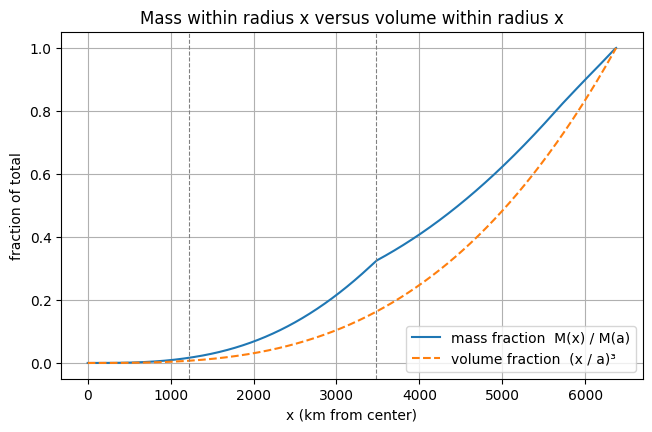

core: 16.3% of the volume, 32.5% of the mass


In [6]:
fig, ax = plt.subplots()
ax.plot(x_vals / 1e3, M_vals / M_a, label='mass fraction  M(x) / M(a)')
ax.plot(x_vals / 1e3, (x_vals / a)**3, '--', label='volume fraction  (x / a)³')
mark_boundaries(ax)
ax.set_xlabel('x (km from center)')
ax.set_ylabel('fraction of total')
ax.set_title('Mass within radius x versus volume within radius x')
ax.legend()
plt.show()

print(f'core: {100 * (R_CMB / a)**3:.1f}% of the volume, {100 * M_exact(R_CMB) / M_a:.1f}% of the mass')

## 5. Inverting M: which sphere contains half of Earth's mass?

To find the radius containing half of the mass we solve $M(x) = \tfrac12 M(a)$.

- A solution **exists** by the intermediate value theorem, since $M$ is continuous and $M(0) = 0 < \tfrac12 M(a)$.
- It is **unique** because $M$ is strictly increasing, since $\rho > 0$.
- We can **find** it by bisection, which produces nested intervals shrinking onto the answer.

For comparison, the sphere containing half of Earth's volume has radius $a/\sqrt[3]{2} \approx 0.794\,a$. That is the same number as the half-full line on a conical glass, because in both cases volume grows like the cube of a length.

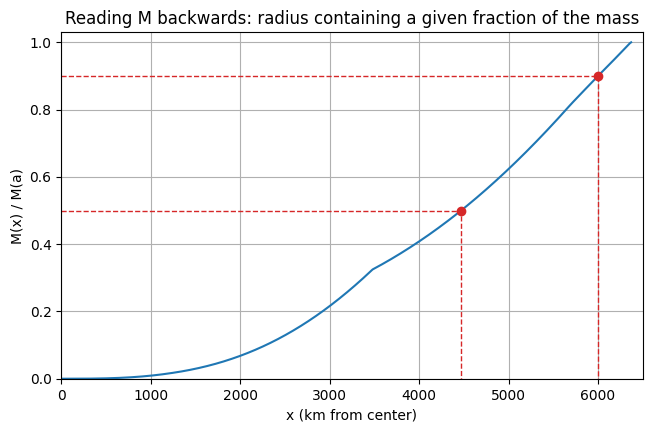

half of the mass lies within 4470 km of the center (0.702 a), i.e. below 1901 km depth
half of the volume lies within 5057 km of the center (0.794 a)
90% of the mass lies deeper than 370 km below the surface


In [7]:
x_half = bisect(M_exact, 0.5 * M_a, 0.0, a)
x_90 = bisect(M_exact, 0.9 * M_a, 0.0, a)

fig, ax = plt.subplots()
ax.plot(x_vals / 1e3, M_vals / M_a)
for frac, xf in [(0.5, x_half), (0.9, x_90)]:
    ax.plot([0, xf / 1e3, xf / 1e3], [frac, frac, 0], '--', color='C3', linewidth=1)
    ax.plot(xf / 1e3, frac, 'o', color='C3')
ax.set_xlim(0, a / 1e3 * 1.02); ax.set_ylim(0, 1.03)
ax.set_xlabel('x (km from center)')
ax.set_ylabel('M(x) / M(a)')
ax.set_title('Reading M backwards: radius containing a given fraction of the mass')
plt.show()

print(f'half of the mass lies within {x_half / 1e3:.0f} km of the center ({x_half / a:.3f} a), i.e. below {(a - x_half) / 1e3:.0f} km depth')
print(f'half of the volume lies within {a / 2**(1/3) / 1e3:.0f} km of the center ({1 / 2**(1/3):.3f} a)')
print(f'90% of the mass lies deeper than {(a - x_90) / 1e3:.0f} km below the surface')

## 6. Average density and the mean value theorem

The average density inside radius $x$ is

$$\bar\rho(x) = \frac{M(x)}{\tfrac43 \pi x^3}.$$

For the whole Earth this is about 5.5 g/cm³, twice the density of surface rock. That number, first measured by Cavendish in 1798, was early evidence that Earth's interior is much denser than its surface.

C&J's generalized mean value theorem (formula (14), with weight $4\pi u^2$) says that if $\rho$ is **continuous**, the average $\bar\rho(x)$ equals $\rho(\xi)$ for some $\xi$ between $0$ and $x$. PREM's density is not continuous, and the conclusion genuinely fails. For the values of $x$ shaded in red below, the average density falls into a gap that $\rho$ jumps over at the inner core boundary or the core-mantle boundary, so no layer inside radius $x$ has exactly the average density.

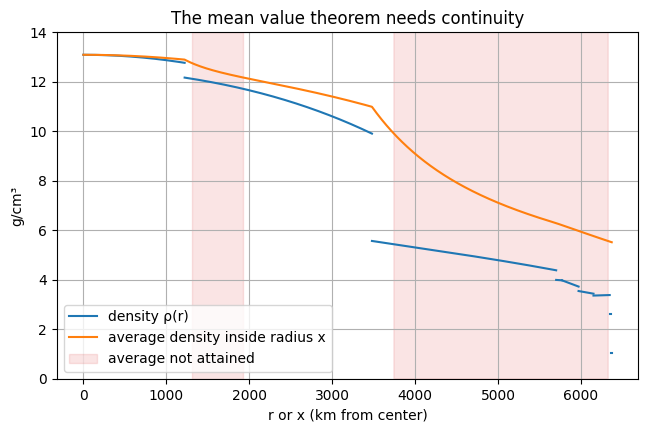

average density of the whole Earth: 5.51 g/cm³


In [8]:
rho_bar = M_vals / (4 / 3 * np.pi * x_vals**3)

def attained(value, x):
    # rho is continuous on each layer, so on each layer it takes every value between its min and max
    for r0, r1, name, c in PREM_LAYERS:
        lo, hi = r0 * 1e3, min(r1 * 1e3, x)
        if hi <= lo:
            break
        v = rho(np.linspace(lo, hi - 1e-6, 400))
        if v.min() <= value <= v.max():
            return True
    return False

ok = np.array([attained(rb, x) for x, rb in zip(x_vals, rho_bar)])

fig, ax = plt.subplots()
plot_layers(lambda r: rho(r) / 1000, ax, color='C0', label='density ρ(r)')
ax.plot(x_vals / 1e3, rho_bar / 1000, color='C1', label='average density inside radius x')
ax.fill_between(x_vals / 1e3, 0, 14, where=~ok, color='C3', alpha=0.12, label='average not attained')
ax.set_ylim(0, 14)
ax.set_xlabel('r or x (km from center)')
ax.set_ylabel('g/cm³')
ax.set_title('The mean value theorem needs continuity')
ax.legend(loc='lower left')
plt.show()

print(f'average density of the whole Earth: {rho_bar[-1] / 1000:.2f} g/cm³')

## 7. Gravity inside the Earth

Taking one fact from physics as a black box (Newton's shell theorem), the strength of gravity at distance $x$ from the center depends only on the mass inside radius $x$:

$$g(x) = \frac{G\,M(x)}{x^2}.$$

For a uniform Earth this would make gravity decrease steadily as you descend, in proportion to $x$ (dashed line). For the real Earth, gravity stays nearly constant through most of the mantle and is actually **strongest at the core-mantle boundary**, about 9% stronger than at the surface. Going down through the mantle, $M(x)$ shrinks, but $x^2$ shrinks just as fast, because the mantle is much less dense than the average of the material below it.

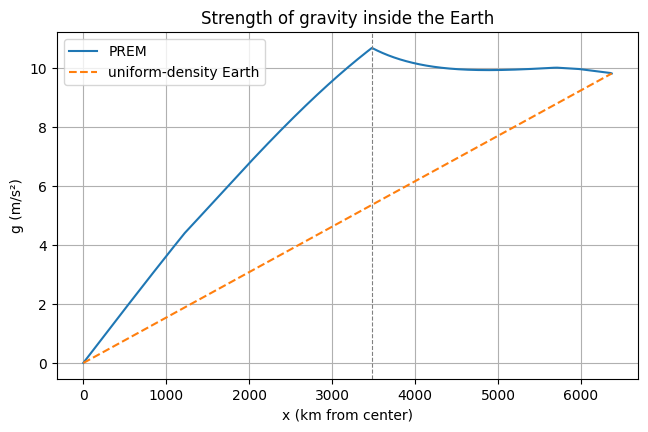

surface gravity 9.82 m/s²; maximum 10.69 m/s² at x = 3481 km


In [9]:
g_vals = G * M_vals / x_vals**2
g_surface = g_vals[-1]

fig, ax = plt.subplots()
ax.plot(x_vals / 1e3, g_vals, label='PREM')
ax.plot(x_vals / 1e3, g_surface * x_vals / a, '--', label='uniform-density Earth')
ax.axvline(R_CMB / 1e3, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('x (km from center)')
ax.set_ylabel('g (m/s²)')
ax.set_title('Strength of gravity inside the Earth')
ax.legend()
plt.show()

k = g_vals.argmax()
print(f'surface gravity {g_surface:.2f} m/s²; maximum {g_vals[k]:.2f} m/s² at x = {x_vals[k] / 1e3:.0f} km')

## Summary

A single function, $M(x) = \int_0^x 4\pi u^2\rho(u)\,du$, answered every question in this demonstration:

- its value at $x = a$ is Earth's mass,
- its values at the layer boundaries give the mass of the core and of each layer,
- its inverse gives the sphere containing half or 90% of the mass,
- dividing by volume gives the average density, and
- dividing by $x^2$ gives the strength of gravity at every depth.

Along the way it illustrated the main facts about indefinite integrals: $\int_\alpha^\beta = \Phi(\beta) - \Phi(\alpha)$, the indefinite integral is continuous (indeed Lipschitz) even when the integrand jumps, and a positive integrand makes it strictly increasing, so it can be inverted.

Reference: A. M. Dziewonski and D. L. Anderson, "Preliminary reference Earth model," *Physics of the Earth and Planetary Interiors* 25 (1981), 297–356.